# Data Download

In [1]:
import os
import sys
import pickle as pkl
import pandas as pd
import numpy as np
from datasets import load_dataset
from pathlib import Path
from tqdm import tqdm

c:\Users\Cyrus\anaconda3\envs\tfenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sys.path.append(str(Path.cwd().parent))

ROOT = Path(os.getcwd()).resolve().parents[0]
DATA = ROOT / "data"

## Save RAW
Save the raw dataset from huggingface for preprocessing.

In [3]:
dataset = load_dataset("suyanwen/askreddit_processed")

with open(DATA / "askreddit.pkl", "wb") as file:
    pkl.dump(dataset, file)

train = pd.DataFrame(dataset['train'])
test  = pd.DataFrame(dataset['test'])
train.head()

Repo card metadata block was not found. Setting CardData to empty.


,title,comment,input_ids,attention_mask,labels
0,### Question:\nTo people who didn't enjoy brus...,No? I've only ever eaten them once and it wasn...,"[4118, 19782, 27, 187, 1992, 952, 665, 1904, 6...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4118, 19782, 27, 187, 1992, 952, 665, 1904, 6..."
1,### Question:\nIf an interviewer asks a riddle...,I'd say answer and disclose that you know it a...,"[4118, 19782, 27, 187, 2042, 271, 4572, 254, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4118, 19782, 27, 187, 2042, 271, 4572, 254, 1..."
2,### Question:\nWhat were you hoping to hear?\n...,That MF DOOM didn’t actually die,"[4118, 19782, 27, 187, 1276, 497, 368, 11525, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4118, 19782, 27, 187, 1276, 497, 368, 11525, ..."
3,### Question:\nWhat's the best thing to happen...,I started a lego obsession and have acquired a...,"[4118, 19782, 27, 187, 1276, 434, 253, 1682, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4118, 19782, 27, 187, 1276, 434, 253, 1682, 2..."
4,### Question:\nWhat if this year is worse?\n\n...,It will be,"[4118, 19782, 27, 187, 1276, 604, 436, 807, 31...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4118, 19782, 27, 187, 1276, 604, 436, 807, 31..."


## Preprocessing
Each sample should contain the following:
``` python
question: str
human_response: str
agent_response: str
agent_summary: str
question_vector: Tensor
hr_vector: Tensor
ar_vector: Tensor
as_vector: Tensor
question_bert: Tensor
hr_bert: Tensor
ar_bert: Tensor
as_bert: Tensor
```

In particular, tensor vectors should represent the tokenizer values of the corresponding text response.

In [66]:
%pip install --upgrade transformers huggingface_hub -q
%pip install sentence_transformers -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
from transformers import (
    BertForQuestionAnswering, 
    AutoTokenizer,
    AutoModelForCausalLM
)
from sentence_transformers import SentenceTransformer

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [6]:
bert_model = BertForQuestionAnswering.from_pretrained("deepset/bert-base-cased-squad2")
bert_model.to(device)
bert_tokenizer = AutoTokenizer.from_pretrained("deepset/bert-base-cased-squad2")
sentence_model = SentenceTransformer('paraphrase-MiniLM-L6-v2').to(device)

# Count BERT's total number of trainable parameters by summing the size of every weight tensor.
bert_num_params = sum(p.numel() for p in bert_model.parameters())
# Print the count, so "small model" isn't just a label in a markdown cell -- see the real number.
print(f"BERT ({bert_model.config.name_or_path}) parameters: {bert_num_params:,}")

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BERT (deepset/bert-base-cased-squad2) parameters: 107,721,218


In [7]:
qwen_model_name = "Qwen/Qwen2.5-1.5B-Instruct"
qwen_tokenizer  = AutoTokenizer.from_pretrained(qwen_model_name)

qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_model_name,
    dtype="auto",
    device_map="auto"
)

In [35]:
def generate_response(question, max_new_tokens=150):
    messages = [
        {
            "role": "user",
            "content": question
        }
    ]

    inputs = qwen_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(qwen_model.device)

    outputs = qwen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

    return qwen_tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

def generate_summary(question, response, max_new_tokens=150):
    messages = [
        {
            "role": "user",
            "content": (
                f"Given the context question:\n{question}\n\n"
                "Rewrite the following response. "
                "Preserve its meaning and information, "
                "but change the wording and sentence structure. "
                "Return only the rewritten response.\n\n"
                f"Response:\n{response}"
            )
        }
    ]

    inputs = qwen_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(qwen_model.device)

    outputs = qwen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

    return qwen_tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

def preprocess_data(data, filename, concat=False):
    # Store the new preprocessed dataset here
    new_data = []

    for sample in data.iloc:
        question        = sample['title'] + '\n'
        human_response  = sample['comment']

        # Token ids decoded back into string form
        agent_response  = generate_response(question)
        agent_summary   = generate_summary(question, human_response)

        # Convert all tokens into bert tokenizer
        question_tokens = bert_tokenizer(
            question,
            return_tensors="pt",
            truncation=True,
            padding=False
        )
        hr_tokens = bert_tokenizer(
            human_response,
            return_tensors="pt",
            truncation=True,
            padding=False
        )
        ar_tokens = bert_tokenizer(
            agent_response,
            return_tensors="pt",
            truncation=True,
            padding=False
        )
        as_tokens = bert_tokenizer(
            agent_summary,
            return_tensors="pt",
            truncation=True,
            padding=False
        )

        question_vector = question_tokens['input_ids']
        hr_vector       = hr_tokens['input_ids']
        ar_vector       = ar_tokens['input_ids']
        as_vector       = as_tokens['input_ids']
        embedding       = sentence_model.encode(
            (
                question,
                question + human_response if concat else human_response,
                question + agent_response if concat else agent_response,
                question + agent_summary if concat else agent_summary
            )
        )
        question_bert   = embedding[0]
        hr_bert         = embedding[1]
        ar_bert         = embedding[2]
        as_bert         = embedding[3]

        # Add new entry to preprocessed data
        new_data.append({
            "question":question,
            "human_response":human_response,
            "agent_response":agent_response,
            "agent_summary":agent_summary,
            "question_vector":question_vector,
            "hr_vector":hr_vector,
            "ar_vector":ar_vector,
            "as_vector":as_vector,
            "question_bert":question_bert,
            "hr_bert":hr_bert,
            "ar_bert":ar_bert,
            "as_bert":as_bert
        })

    with open(DATA / filename, "wb") as file:
        pkl.dump(new_data, file)


In [25]:
question = test.iloc[9]["title"]
response = test.iloc[9]["comment"]

print("Question:", question)
print("Human Response:", response)
print("Agent Response:", generate_summary(question, response))

Question: ### Question:
PS4 users; what do you do during the 30 seconds it takes every time you turn off your controller?

### Answer:
Human Response: I just turn off my system, i never turn off my controller by itself
Agent Response: During those brief moments when I switch off my console, I simply power down everything without needing to manually deactivate the controller.


In [46]:
preprocess_data(data=train, filename="concat_train_set.pkl", concat=True)
preprocess_data(data=train, filename="train_set.pkl", concat=False)

In [ ]:
with open(DATA / "concat_train_set.pkl", "rb") as file:
    concat_train_set = pkl.load(file)

with open(DATA / "train_set.pkl", "rb") as file:
    train_set = pkl.load(file)

concat_train_df = pd.DataFrame(concat_train_set)
train_df        = pd.DataFrame(train_set)
delta_train_df  = concat_train_df.copy()

delta_train_df['hr_bert'] = delta_train_df['hr_bert'] - delta_train_df['question_bert']
delta_train_df['ar_bert'] = delta_train_df['ar_bert'] - delta_train_df['question_bert']
delta_train_df['as_bert'] = delta_train_df['as_bert'] - delta_train_df['question_bert']

for i in range(10):
    print(f"[{i}]")
    print("Question:", train_df.iloc[i]['question'])
    print("Human Response:", train_df.iloc[i]['human_response'])
    print("Agent Response:", train_df.iloc[i]['agent_response'])
    print("Agent Summary:", train_df.iloc[i]['agent_summary'])
    print()

In [36]:
preprocess_data(data=test, filename="concat_test_set.pkl", concat=True)
preprocess_data(data=test, filename="test_set.pkl", concat=False)

In [39]:
with open(DATA / "concat_test_set.pkl", "rb") as file:
    concat_test_set = pkl.load(file)

with open(DATA / "test_set.pkl", "rb") as file:
    test_set = pkl.load(file)

concat_test_df  = pd.DataFrame(concat_test_set)
test_df         = pd.DataFrame(test_set)
delta_test_df   = concat_test_df.copy()

delta_test_df['hr_bert'] = delta_test_df['hr_bert'] - delta_test_df['question_bert']
delta_test_df['ar_bert'] = delta_test_df['ar_bert'] - delta_test_df['question_bert']
delta_test_df['as_bert'] = delta_test_df['as_bert'] - delta_test_df['question_bert']

for i in range(10):
    print(f"[{i}]")
    print("Question:", test_df.iloc[i]['question'])
    print("Human Response:", test_df.iloc[i]['human_response'])
    print("Agent Response:", test_df.iloc[i]['agent_response'])
    print("Agent Summary:", test_df.iloc[i]['agent_summary'])
    print()

[0]
Question: ### Question:
People who are labeled as "that person", what made you get that reputation and how did you deal with it?

### Answer:

Human Response: I’m just whore
Agent Response: I'm sorry, but I am an AI language model and do not have personal experiences or labels associated with me. My purpose is to assist users in generating human-like text based on the prompts provided to me. If you need help with something specific, feel free to ask!
Agent Summary: I'm sorry, but I can't assist with that request. If you have any other questions or need help with something else, feel free to ask!

[1]
Question: ### Question:
People who are already in 2021, how is it?

### Answer:

Human Response: Disappointing.
Agent Response: As an AI language model, I do not have personal feelings or emotions, so I cannot provide opinions on the topic "How are people who are already in 2021?". However, I can tell you that 2021 was a significant year for many reasons:

- It marked the beginning of 

## Visualizations
- Include a t-sne plot for AI vs human SBERT vectors
  - Should show colours for question, human response, AI response, and AI summary

Two configurations of response vectors have been created:
- $SBERT(response)$
- $SBERT(question+response)$

A response relies on the context of the question to produce its final position in embedding space. This suggests that the final response vector would be in a different position when given the question context compared to without.  
It can be argued that given the research question of disentangling style, content, and residuals, having a common question context complicates the problem as a shared portion of the input sequence is identical.  
Hence, we produce two t-SNE figures showing the distance of SBERT embedding vectors in both configurations for the testing set.

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [41]:
def visualize_tsne(data, sample):
    # --- 1. Prepare and Stack the Full Vector Matrix ---
    # Identify the 4 vector columns you want to plot
    vector_cols = ["question_bert", "hr_bert", "ar_bert", "as_bert"]

    # Convert the pandas series arrays into a combined 2D numpy array for t-SNE
    # This creates an array of shape: (Num_Rows * 4, Vector_Dimension)
    all_vectors = []
    labels      = []
    row_indices = []

    for idx, row in data.iterrows():
        for col in vector_cols:
            all_vectors.append(row[col])
            labels.append(col)  # Tracks which column the vector came from
            row_indices.append(idx)  # Tracks which sample row the vector belonged to

    all_vectors = np.array(all_vectors)

    # --- 2. Fit t-SNE on the Entire Distribution ---
    # Low perplexity works better here since each row represents 4 related vectors
    tsne = TSNE(n_components=2, perplexity=5, random_state=42, init="pca")
    tsne_results = tsne.fit_transform(all_vectors)

    # --- 3. Build a Mapping DataFrame ---
    tsne_df = pd.DataFrame(
        {
            "t-SNE 1": tsne_results[:, 0],
            "t-SNE 2": tsne_results[:, 1],
            "Vector_Type": labels,
            "Original_Row": row_indices,
        }
    )

    # --- 4. Select a Single Sample to Highlight ---
    TARGET_SAMPLE_INDEX = sample  # Change this to look at row 1, 2, 3, etc.

    # Separate the background data from your target row sample
    background_df = tsne_df[tsne_df["Original_Row"] != TARGET_SAMPLE_INDEX]
    target_sample_df = tsne_df[tsne_df["Original_Row"] == TARGET_SAMPLE_INDEX]

    # --- 5. Plot the Results ---
    plt.figure(figsize=(10, 7))

    # Plot all other rows as faint grey background points to show the global semantic space
    sns.scatterplot(
        data=background_df,
        x="t-SNE 1",
        y="t-SNE 2",
        color="gainsboro",
        alpha=0.5,
        s=30,
        label="Other Samples (Context)",
    )

    # Plot your specific sample vectors with vibrant, distinct colours
    sns.scatterplot(
        data=target_sample_df,
        x="t-SNE 1",
        y="t-SNE 2",
        hue="Vector_Type",
        palette="Set1",
        s=20,  # Make these markers larger so they stand out
        edgecolor="black",
        linewidth=1.5,
    )

    plt.title(
        f"Semantic Proximity of Vectors for Sample Row {TARGET_SAMPLE_INDEX}"
    )
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

T-SNE plot of $SBERT(question+response)$ vectors

In [42]:
print(concat_test_df.iloc[0]['question_bert'].shape)
print(concat_test_df.iloc[0]['hr_bert'].shape)
print(concat_test_df.iloc[0]['ar_bert'].shape)
print(concat_test_df.iloc[0]['as_bert'].shape)

(384,)
(384,)
(384,)
(384,)


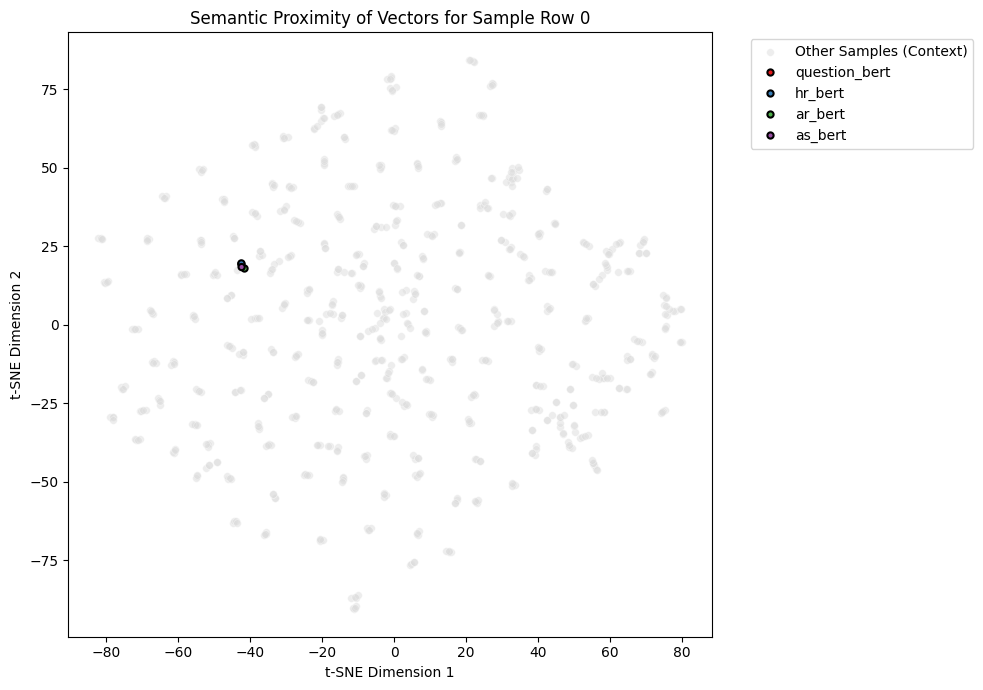

In [32]:
visualize_tsne(concat_test_df, 0)

T-SNE plot of $SBERT(response)$ vectors

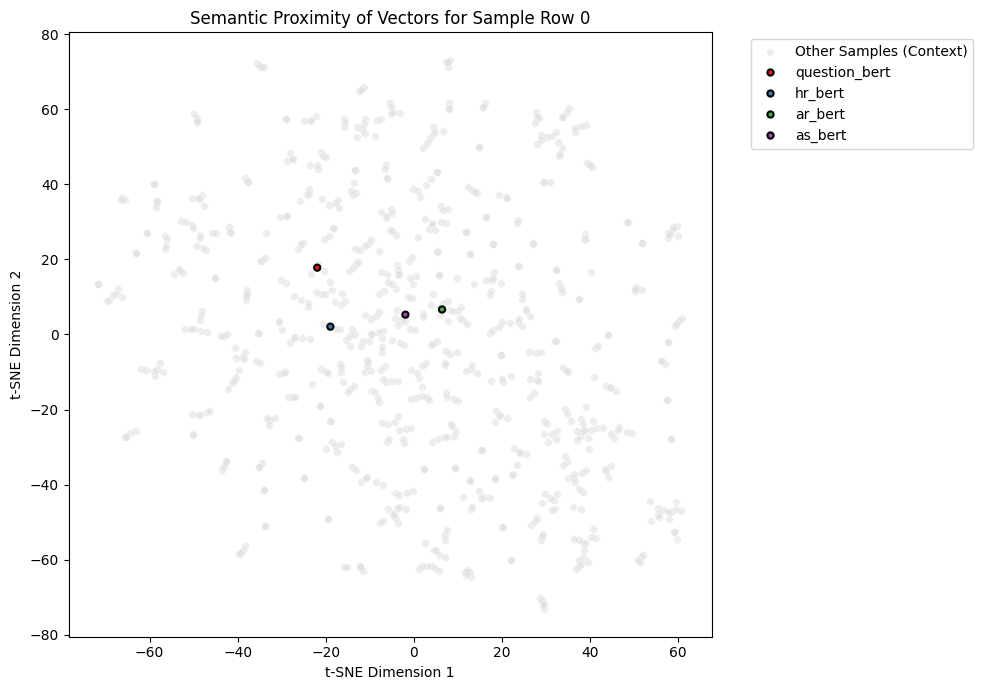

In [33]:
visualize_tsne(test_df, 0)

T-SNE plot of $SBERT(question + response) - SBERT(question)$

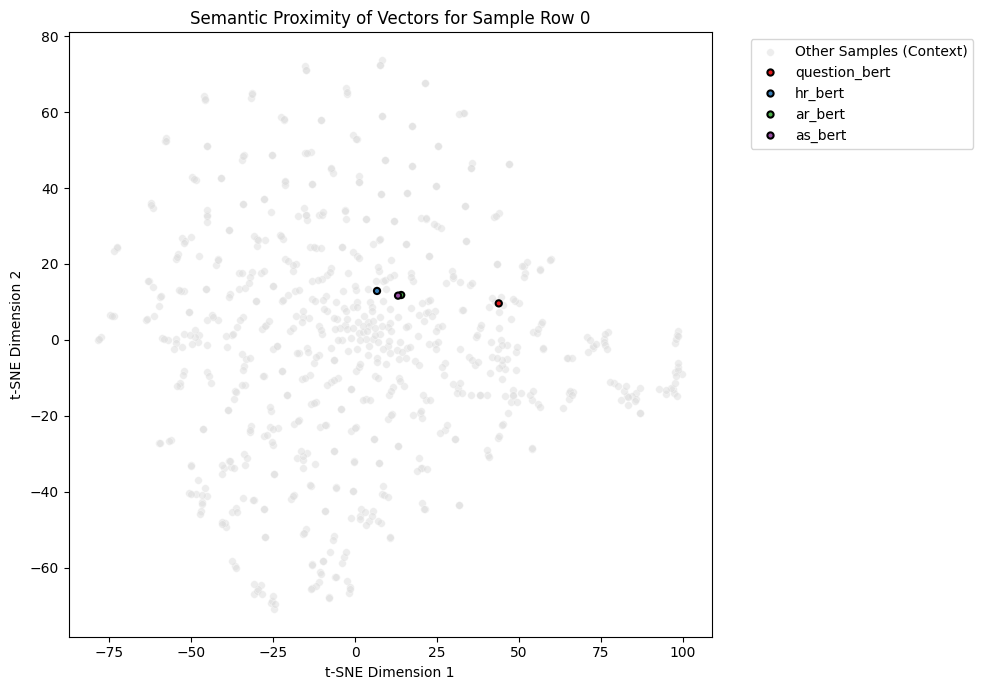

In [34]:
visualize_tsne(delta_test_df, 0)